In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

In [1]:
from sklearn.linear_model import Ridge, Lasso


In [3]:
data = {
    "Area": [800,1000,1200,1500,1800,2000,2200,2500],
    "Bedrooms": [1,2,2,3,3,4,4,5],
    "Age": [20,15,12,10,8,5,3,1],
    "Price": [3000000,4500000,5500000,7000000,8500000,10000000,12000000,15000000]
}


df = pd.DataFrame(data)

df

,Area,Bedrooms,Age,Price
0,800,1,20,3000000
1,1000,2,15,4500000
2,1200,2,12,5500000
3,1500,3,10,7000000
4,1800,3,8,8500000
5,2000,4,5,10000000
6,2200,4,3,12000000
7,2500,5,1,15000000


In [4]:

X = df.drop("Price", axis=1)

y = df["Price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [5]:
linear = LinearRegression()

linear.fit(X_train, y_train)


prediction = linear.predict(X_test)


print("R2 Score:",
      r2_score(y_test,prediction))

R2 Score: 0.9287075081455555


In [6]:
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=1)


ridge.fit(X_train,y_train)


ridge_pred = ridge.predict(X_test)


print(
"Ridge R2:",
r2_score(y_test,ridge_pred)
)

Ridge R2: 0.9345935846118032


In [7]:
from sklearn.linear_model import Lasso


lasso = Lasso(alpha=1)


lasso.fit(X_train,y_train)


lasso_pred = lasso.predict(X_test)


print(
"Lasso R2:",
r2_score(y_test,lasso_pred)
)

Lasso R2: 0.9287079764616563


In [8]:
models = {
    "Linear": linear,
    "Ridge": ridge,
    "Lasso": lasso
}


for name,model in models.items():

    pred = model.predict(X_test)

    print(
        name,
        r2_score(y_test,pred)
    )

Linear 0.9287075081455555
Ridge 0.9345935846118032
Lasso 0.9287079764616563


In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [11]:
X = np.array([
    [500],
    [1000],
    [1500],
    [2000],
    [2500],
    [3000]
])


y = np.array([
    20,
    45,
    80,
    130,
    190,
    260
])

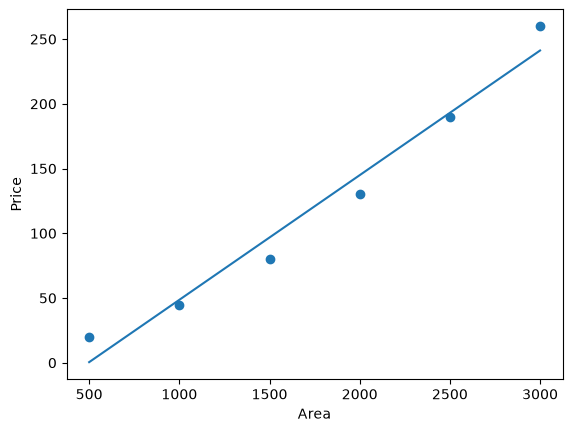

In [12]:
linear = LinearRegression()

linear.fit(X,y)


prediction = linear.predict(X)


plt.scatter(X,y)

plt.plot(
    X,
    prediction
)

plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

In [13]:
poly = PolynomialFeatures(degree=2)


X_poly = poly.fit_transform(X)

In [14]:
model = LinearRegression()


model.fit(X_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0. ,0.02,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[7478441.52, 427.23, 0. ]"


In [15]:
y_pred = model.predict(X_poly)

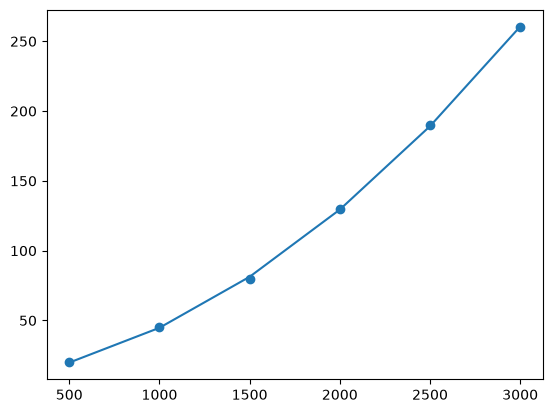

In [16]:
plt.scatter(X,y)

plt.plot(
    X,
    y_pred
)

plt.show()

In [17]:
from sklearn.metrics import r2_score


for degree in range(1,6):

    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)


    model = LinearRegression()

    model.fit(X_poly,y)


    pred = model.predict(X_poly)


    print(
        "Degree:",
        degree,
        "Score:",
        r2_score(y,pred)
    )

Degree: 1 Score: 0.9698600890989055
Degree: 2 Score: 0.999927411434834
Degree: 3 Score: 0.9999435527613889
Degree: 4 Score: 0.9977581316022464
Degree: 5 Score: 0.989876146138957
